# 02 — Structure du marché hôtelier tunisien
Objectif : cartographier la couverture du jeu de données avant la modélisation.

**Source des données :** PostgreSQL `hotel_features` (pipeline feature engineering complet).  
**Requêtes :** agrégations SQL prioritaires ; pas de chargement complet en mémoire.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text
from pathlib import Path
import sys
sys.path.insert(0, "..")
from feature_engineering.config import POSTGRES_URI

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({"savefig.dpi": 300, "figure.dpi": 120})

engine = create_engine(POSTGRES_URI)

FIGURES_DIR = Path("figures/02_market_structure")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name: str) -> None:
    path = FIGURES_DIR / f"{name}.png"
    plt.savefig(path, bbox_inches="tight")
    print(f"Enregistré → {path}")

## 1. Paysage hôtelier par ville

Enregistré → figures\02_market_structure\01_hotels_par_ville.png


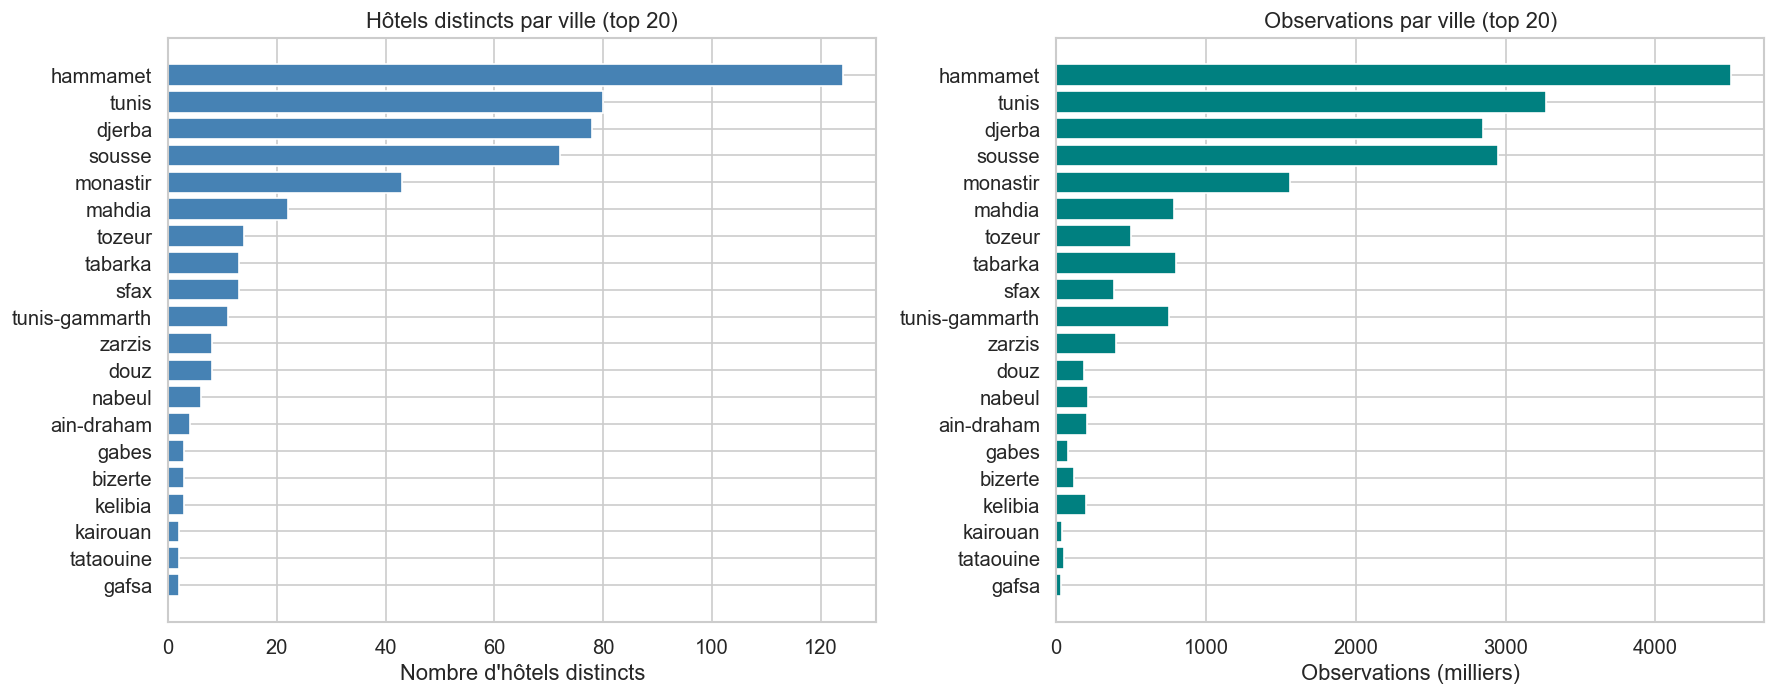

,city_name,n_hotels,n_rows
0,hammamet,124,4503591
1,tunis,80,3267115
2,djerba,78,2846629
3,sousse,72,2950701
4,monastir,43,1560799
5,mahdia,22,783152
6,tozeur,14,497004
7,tabarka,13,800901
8,sfax,13,384973
9,tunis-gammarth,11,754715


In [2]:
city_q = pd.read_sql("""
    SELECT city_name,
           COUNT(DISTINCT hotel_name_normalized) AS n_hotels,
           COUNT(*) AS n_rows
    FROM hotel_features
    GROUP BY city_name
    ORDER BY n_hotels DESC
    LIMIT 20
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hôtels par ville
axes[0].barh(city_q["city_name"][::-1], city_q["n_hotels"][::-1], color="steelblue")
axes[0].set_xlabel("Nombre d'hôtels distincts")
axes[0].set_title("Hôtels distincts par ville (top 20)")

# Observations par ville
axes[1].barh(city_q["city_name"][::-1], city_q["n_rows"][::-1] / 1000, color="teal")
axes[1].set_xlabel("Observations (milliers)")
axes[1].set_title("Observations par ville (top 20)")

plt.tight_layout()
save_fig("01_hotels_par_ville")
plt.show()
city_q

Enregistré → figures\02_market_structure\01b_distribution_etoiles.png


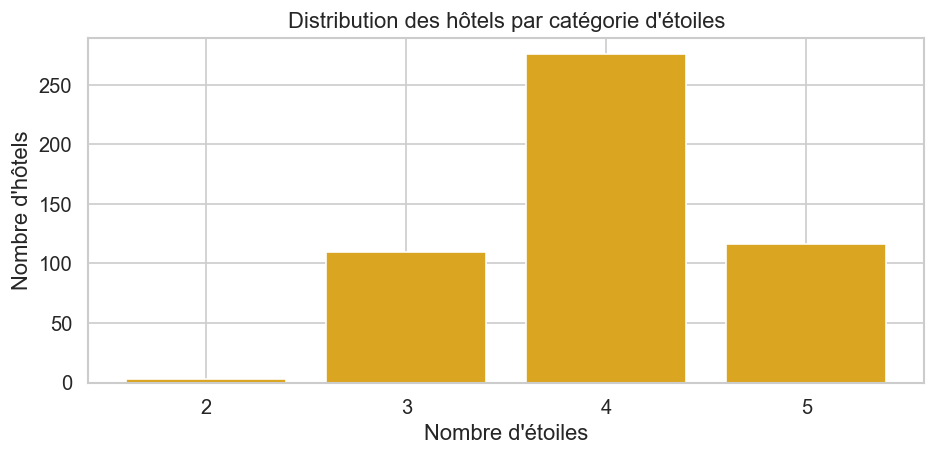

,stars_int,n_rows,n_hotels
0,2,26939,3
1,3,2141896,110
2,4,9815391,276
3,5,7892611,116


In [3]:
stars_q = pd.read_sql("""
    SELECT stars_int, COUNT(*) AS n_rows,
           COUNT(DISTINCT hotel_name_normalized) AS n_hotels
    FROM hotel_features
    GROUP BY stars_int
    ORDER BY stars_int
""", engine)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(stars_q["stars_int"].astype(str), stars_q["n_hotels"], color="goldenrod")
ax.set_xlabel("Nombre d'étoiles")
ax.set_ylabel("Nombre d'hôtels")
ax.set_title("Distribution des hôtels par catégorie d'étoiles")
plt.tight_layout()
save_fig("01b_distribution_etoiles")
plt.show()
stars_q

## 2. Équilibre des sources

Enregistré → figures\02_market_structure\02_equilibre_sources.png


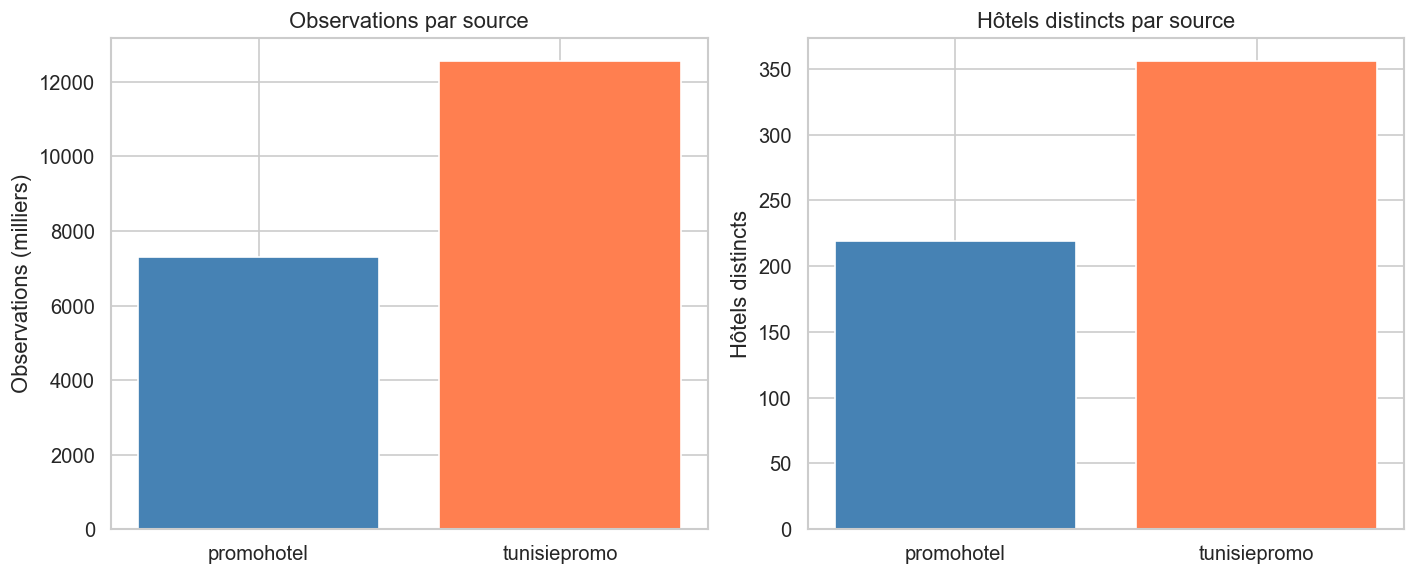

,source,n_hotels,n_rows
0,promohotel,219,7315568
1,tunisiepromo,356,12561269


In [4]:
source_q = pd.read_sql("""
    SELECT source,
           COUNT(DISTINCT hotel_name_normalized) AS n_hotels,
           COUNT(*) AS n_rows
    FROM hotel_features
    GROUP BY source
""", engine)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = source_q["source"].tolist()

axes[0].bar(labels, source_q["n_rows"] / 1000, color=["steelblue", "coral"])
axes[0].set_ylabel("Observations (milliers)")
axes[0].set_title("Observations par source")

axes[1].bar(labels, source_q["n_hotels"], color=["steelblue", "coral"])
axes[1].set_ylabel("Hôtels distincts")
axes[1].set_title("Hôtels distincts par source")

plt.tight_layout()
save_fig("02_equilibre_sources")
plt.show()
source_q

Enregistré → figures\02_market_structure\02b_mix_sources_villes.png


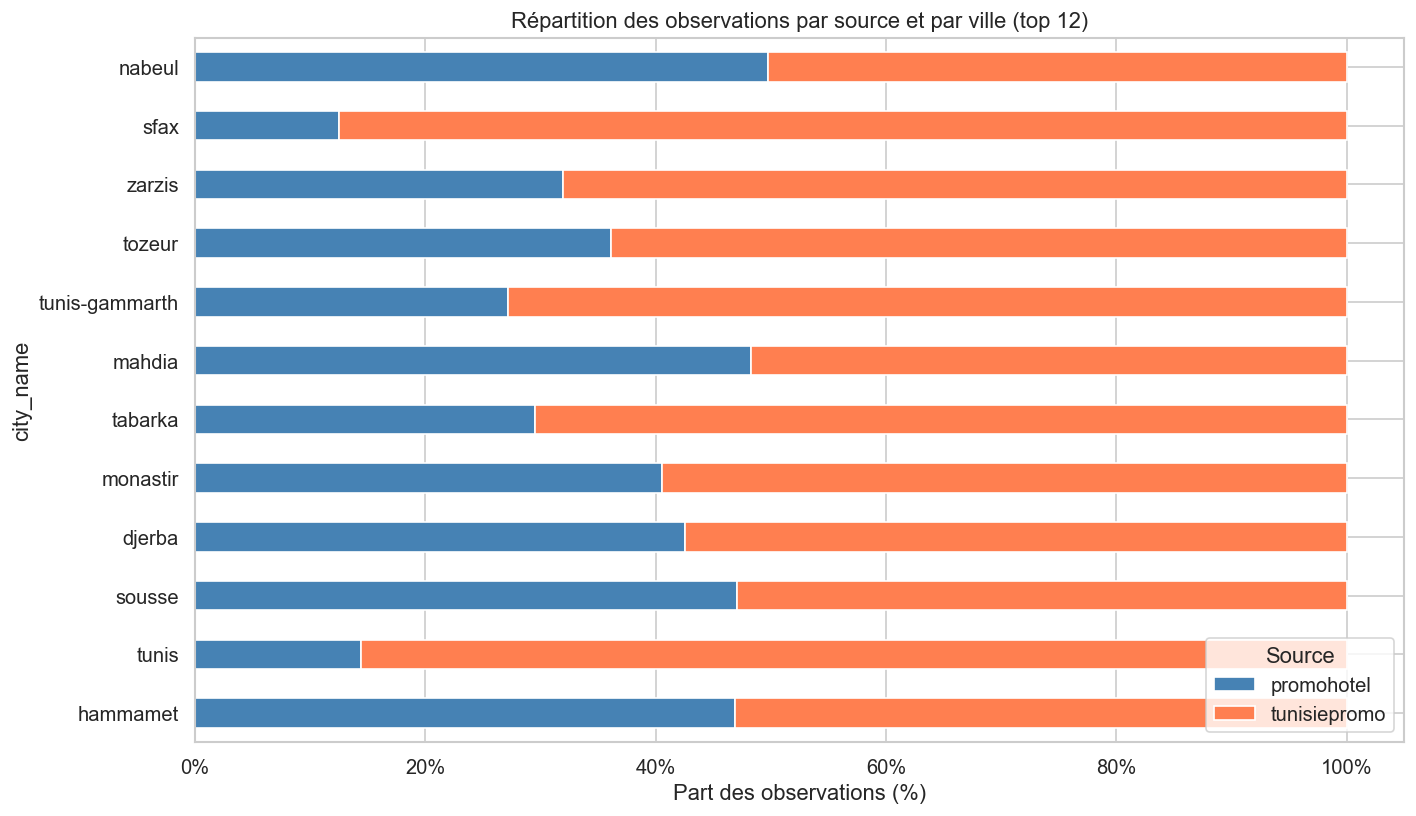

In [5]:
city_source_q = pd.read_sql("""
    SELECT city_name, source, COUNT(*) AS n_rows
    FROM hotel_features
    GROUP BY city_name, source
    ORDER BY city_name
""", engine)

pivot = city_source_q.pivot(index="city_name", columns="source", values="n_rows").fillna(0)
# Top 12 cities by total
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.nlargest(12, "total").drop(columns="total")

ax = pivot.div(pivot.sum(axis=1), axis=0).plot(
    kind="barh", stacked=True, figsize=(12, 7),
    color=["steelblue", "coral"]
)
ax.set_xlabel("Part des observations (%)")
ax.set_title("Répartition des observations par source et par ville (top 12)")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(title="Source", loc="lower right")
plt.tight_layout()
save_fig("02b_mix_sources_villes")
plt.show()

## 3. Correspondance inter-sources

Enregistré → figures\02_market_structure\03_correspondance_sources.png


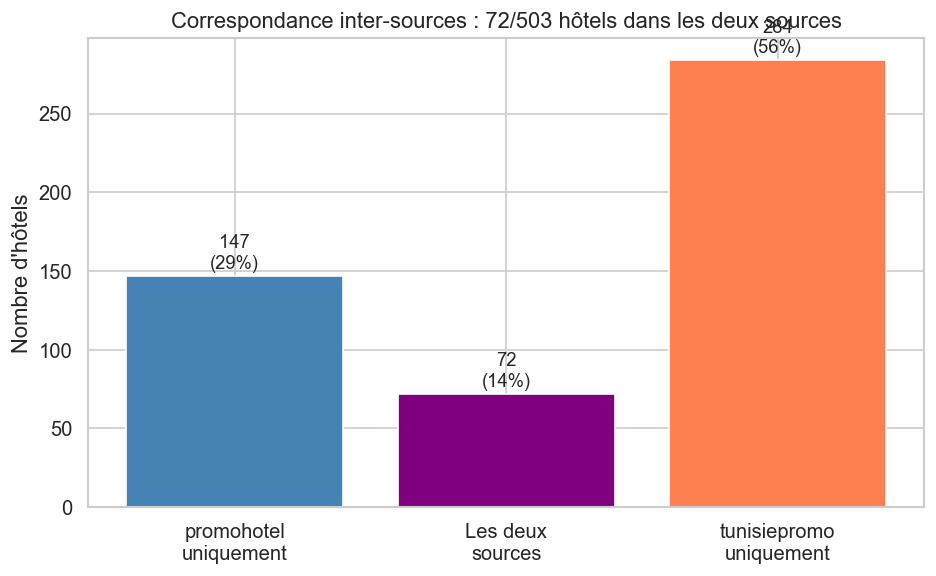

Total hôtels : 503
Dans les deux sources : 72 (14.3%)
Mono-source (risque de modélisation) : 431 (85.7%)


In [6]:
hotel_source_q = pd.read_sql("""
    SELECT hotel_name_normalized, source
    FROM hotel_features
    GROUP BY hotel_name_normalized, source
""", engine)

by_source = hotel_source_q.groupby("hotel_name_normalized")["source"].apply(set)
sources_list = source_q["source"].tolist()

# Categorize
only_a = int((by_source.apply(lambda s: len(s) == 1 and sources_list[0] in s)).sum())
only_b = int((by_source.apply(lambda s: len(s) == 1 and sources_list[-1] in s)).sum())
both   = int((by_source.apply(lambda s: len(s) == 2)).sum())
total  = only_a + only_b + both

fig, ax = plt.subplots(figsize=(8, 5))
cats = [f"{sources_list[0]}\nuniquement", "Les deux\nsources", f"{sources_list[-1]}\nuniquement"]
vals = [only_a, both, only_b]
bars = ax.bar(cats, vals, color=["steelblue", "purple", "coral"])
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f"{val}\n({val/total*100:.0f}%)", ha="center", va="bottom", fontsize=11)
ax.set_ylabel("Nombre d'hôtels")
ax.set_title(f"Correspondance inter-sources : {both}/{total} hôtels dans les deux sources")
plt.tight_layout()
save_fig("03_correspondance_sources")
plt.show()

print(f"Total hôtels : {total}")
print(f"Dans les deux sources : {both} ({both/total*100:.1f}%)")
print(f"Mono-source (risque de modélisation) : {only_a + only_b} ({(only_a+only_b)/total*100:.1f}%)")

## 4. Couverture taxonomique des chambres

Enregistré → figures\02_market_structure\04_couverture_taxonomie_chambres.png


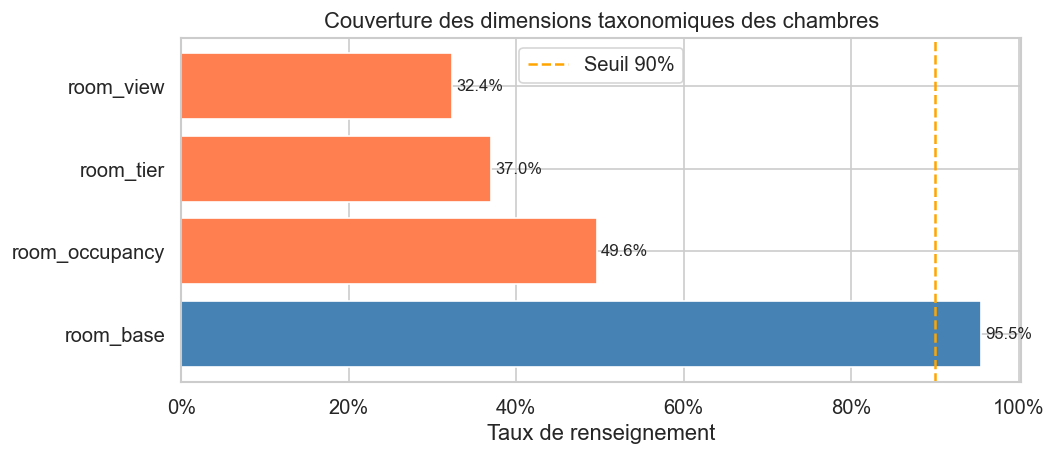

In [7]:
# Values from validation_20260430T105005Z.json
coverage = {
    "room_base": 0.9552,
    "room_occupancy": 0.4963,
    "room_tier": 0.3701,
    "room_view": 0.3239,
}

fig, ax = plt.subplots(figsize=(9, 4))
cols = list(coverage.keys())
vals = [coverage[c] for c in cols]
colors = ["steelblue" if v >= 0.9 else "coral" for v in vals]
ax.barh(cols, vals, color=colors)
ax.axvline(0.9, color="orange", linestyle="--", linewidth=1.5, label="Seuil 90%")
ax.set_xlabel("Taux de renseignement")
ax.set_title("Couverture des dimensions taxonomiques des chambres")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
for i, (c, v) in enumerate(zip(cols, vals)):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=10)
plt.tight_layout()
save_fig("04_couverture_taxonomie_chambres")
plt.show()

In [8]:
# Top-20 room names not matched by room_base regex
unmatched_q = pd.read_sql("""
    SELECT room_name, COUNT(*) AS n
    FROM hotel_features
    WHERE room_base IS NULL
    GROUP BY room_name
    ORDER BY n DESC
    LIMIT 20
""", engine)
print("Top-20 noms de chambre non couverts par la taxonomie :")
unmatched_q

Top-20 noms de chambre non couverts par la taxonomie :


,room_name,n
0,Standard Vue Jardin,52685
1,Familiale Supérieure,29426
2,Standard Vue Mer,28206
3,Quadruple Vue Jardin,26831
4,Standard Vue Piscine,26135
5,Quadruple Vue Jardin,24140
6,Twin GardenView1,23193
7,Twin SeaView,23193
8,Triple vue Jardin,22265
9,Double vue Jardin,22265


## 5. Densité des données (ville × mois)

Enregistré → figures\02_market_structure\05_densite_ville_mois.png


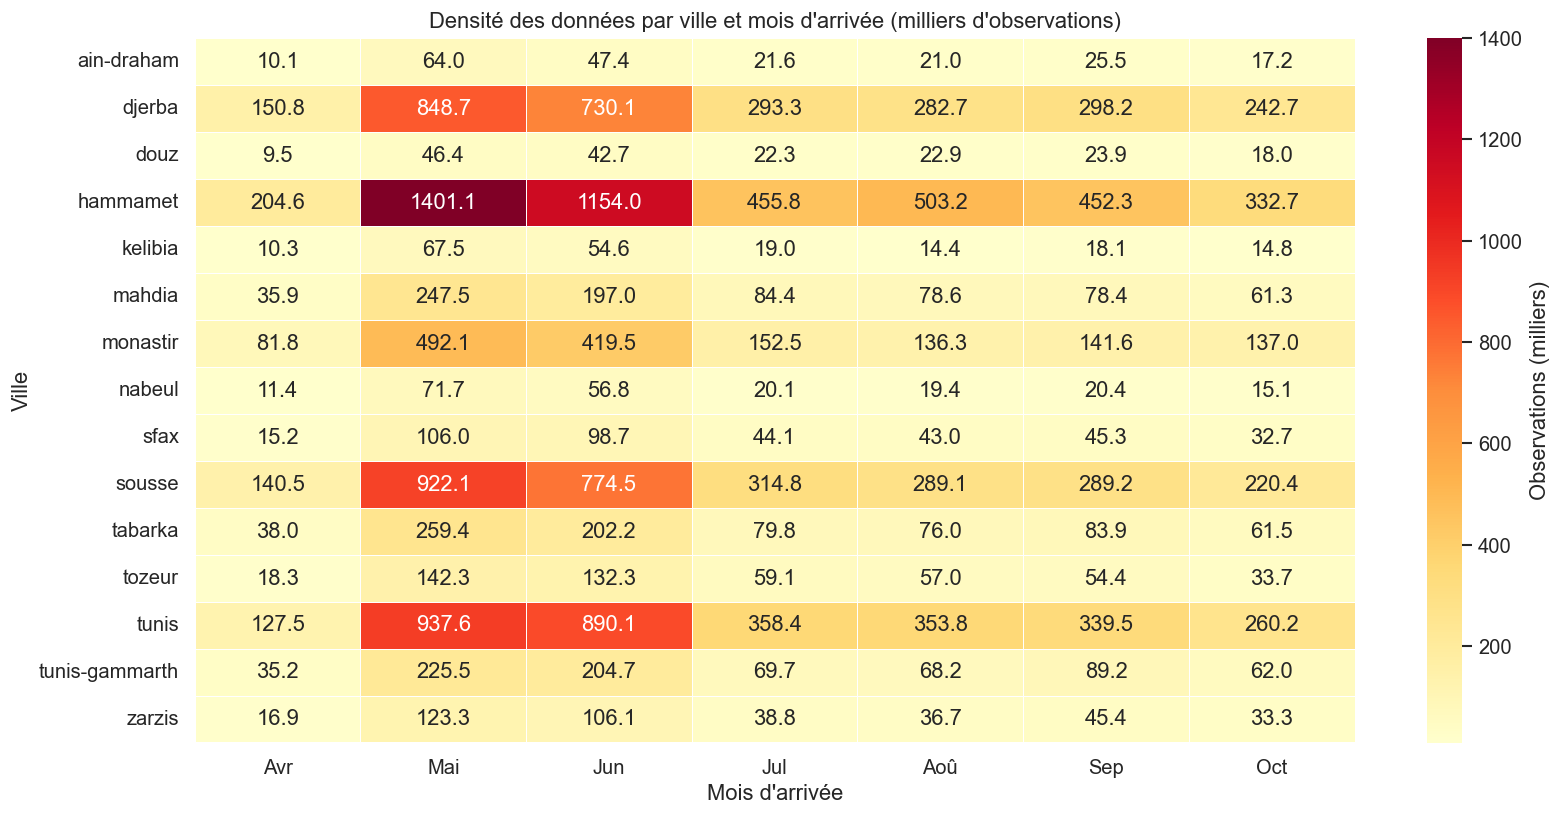

In [9]:
density_q = pd.read_sql("""
    SELECT city_name, check_in_month, COUNT(*) AS n_rows
    FROM hotel_features
    GROUP BY city_name, check_in_month
    ORDER BY city_name, check_in_month
""", engine)

# Keep top-15 cities by total rows
top_cities = (
    density_q.groupby("city_name")["n_rows"].sum()
    .nlargest(15).index.tolist()
)
density_q = density_q[density_q["city_name"].isin(top_cities)]

pivot = density_q.pivot(index="city_name", columns="check_in_month", values="n_rows").fillna(0)
MOIS = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]
pivot.columns = [MOIS[m-1] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot / 1000, annot=True, fmt=".1f", cmap="YlOrRd",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Observations (milliers)"}
)
ax.set_title("Densité des données par ville et mois d'arrivée (milliers d'observations)")
ax.set_xlabel("Mois d'arrivée")
ax.set_ylabel("Ville")
plt.tight_layout()
save_fig("05_densite_ville_mois")
plt.show()

## Conclusions pour la modélisation

- **Couverture géographique** : le dataset couvre plusieurs villes tunisiennes ; les premières villes concentrent la majorité des observations. Les cellules creuses (ville × mois) produiront des agrégats pairs moins fiables — le modèle devra s'appuyer sur la granularité *loose* dans ces zones.

- **Déséquilibre inter-sources** : promohotel et tunisiepromo contribuent de façon inégale selon les villes. Les hôtels mono-source (majorité) ont des groupes pairs source-homogènes, ce qui réduit la diversité de la comparaison compétitive.

- **Correspondance inter-sources** : ~66/490 hôtels apparaissent dans les deux sources → risque de modélisation pour les ~424 hôtels mono-source. Le matching par `hotel_name_normalized` est correct pour les hôtels présents dans les deux sources ; un fuzzy matching pourrait améliorer la couverture croisée.

- **Taxonomie des chambres** : `room_base` est bien couvert (95,5 %). `room_view` (32 %), `room_tier` (37 %), `room_occupancy` (50 %) sont partiellement renseignés — attendu, car tous les noms de chambre n'encodent pas ces dimensions. Le groupe pair *tight* (qui utilise `room_base` + `room_view`) atteint 86,8 % de couverture, le reste se repliant sur *medium*.

- **Densité saisonnière** : certains (ville, mois) sont peu denses (< 1 000 observations) — les tranches correspondantes produiront des agrégats pairs moins fiables. À surveiller lors de la validation du modèle.